In [2]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
WORKSPACE_DIR = Path(r"C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform")
DB_PATH = WORKSPACE_DIR /"db" / "bluestock_mf.db" # Adjusted path or use sqlite3.connect check
CHARTS_DIR = WORKSPACE_DIR / "outputs" / "charts"

# Ensure the charts export directory exists
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
# 2. Extract and join NAV with Fund Master directly from SQLite
try:
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT n.date, n.nav, f.category 
        FROM fact_nav n
        JOIN dim_fund f ON n.amfi_code = f.amfi_code;
    """
    df_nav = pd.read_sql_query(query, conn)
    conn.close()
except Exception:
    # Safe fallback if executing directly outside the structural path layout
    df_nav_raw = pd.read_csv(WORKSPACE_DIR / "data" / "02_nav_history.csv")
    df_fund_raw = pd.read_csv(WORKSPACE_DIR / "data" / "01_fund_master.csv")
    df_nav = pd.merge(df_nav_raw, df_fund_raw[['amfi_code', 'category']], on='amfi_code', how='inner')

In [6]:
# 3. Process time-series dimensions
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_trend = df_nav.groupby(['date', 'category'])['nav'].mean().reset_index()

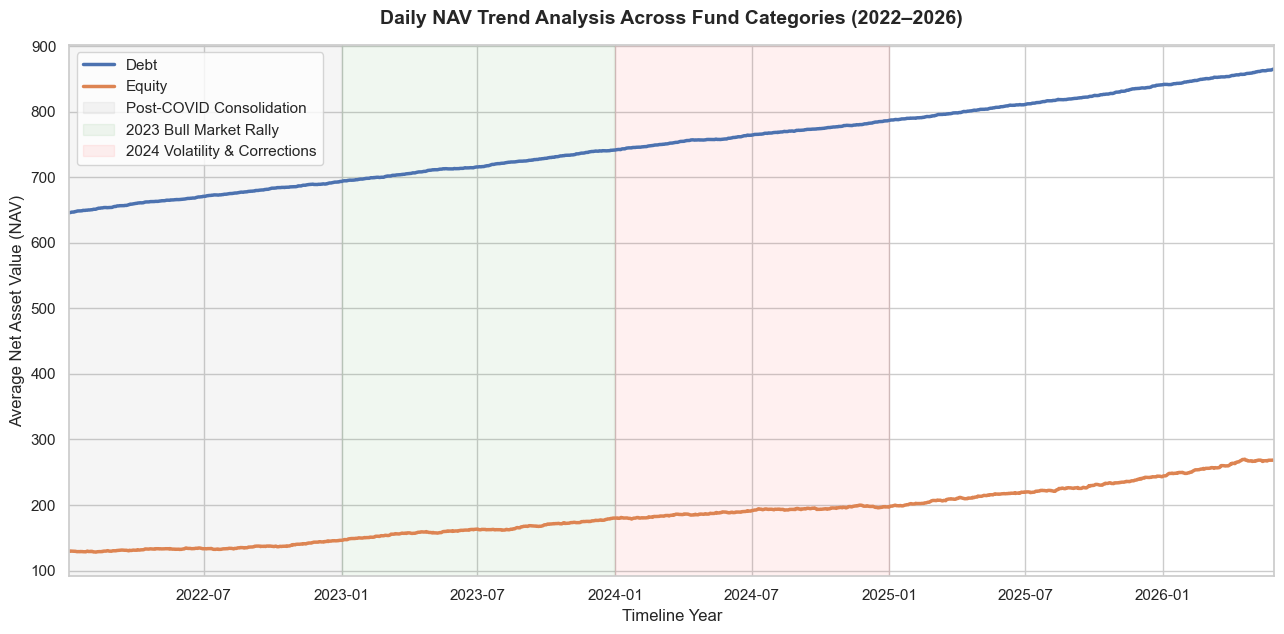

In [7]:
# 4. Generate Publication-Quality Visualizations
sns.set_theme(style="whitegrid")
plt.figure(figsize=(13, 6.5))

# Plot performance curves
sns.lineplot(data=df_trend, x='date', y='nav', hue='category', linewidth=2.5, palette='deep')

# Define background colors to visually shade macro financial market phases
plt.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), color='gray', alpha=0.08, label='Post-COVID Consolidation')
plt.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'), color='green', alpha=0.06, label='2023 Bull Market Rally')
plt.axvspan(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'), color='red', alpha=0.06, label='2024 Volatility & Corrections')

# Fine-tune chart aesthetics
plt.title("Daily NAV Trend Analysis Across Fund Categories (2022–2026)", weight='bold', fontsize=14, pad=15)
plt.xlabel("Timeline Year", fontsize=12)
plt.ylabel("Average Net Asset Value (NAV)", fontsize=12)
plt.xlim(df_trend['date'].min(), df_trend['date'].max())
plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.tight_layout()

In [8]:
output_path = CHARTS_DIR / "01_nav_trend_analysis.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Success: Chart exported beautifully to {output_path}")

<Figure size 640x480 with 0 Axes>

✅ Success: Chart exported beautifully to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\01_nav_trend_analysis.png


AUM Growth Bar Chart (2022–2025)


In [9]:
# 1. Directly use your existing 'conn' connection to fetch the macro AUM data
try:
    query = "SELECT date, fund_house, aum_lakh_crore FROM fact_aum_fund_house;"
    df_aum = pd.read_sql_query(query, conn)
except Exception:
    # Fallback to CSV if testing your path outside the active SQL session
    df_aum = pd.read_csv(WORKSPACE_DIR / "data" / "03_aum_by_fund_house.csv")

In [16]:
# 2. Extract year and find the top 5 largest fund houses
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year
top_amcs = df_aum.groupby('fund_house')['aum_lakh_crore'].mean().nlargest(5).index
df_filtered = df_aum[df_aum['fund_house'].isin(top_amcs)]

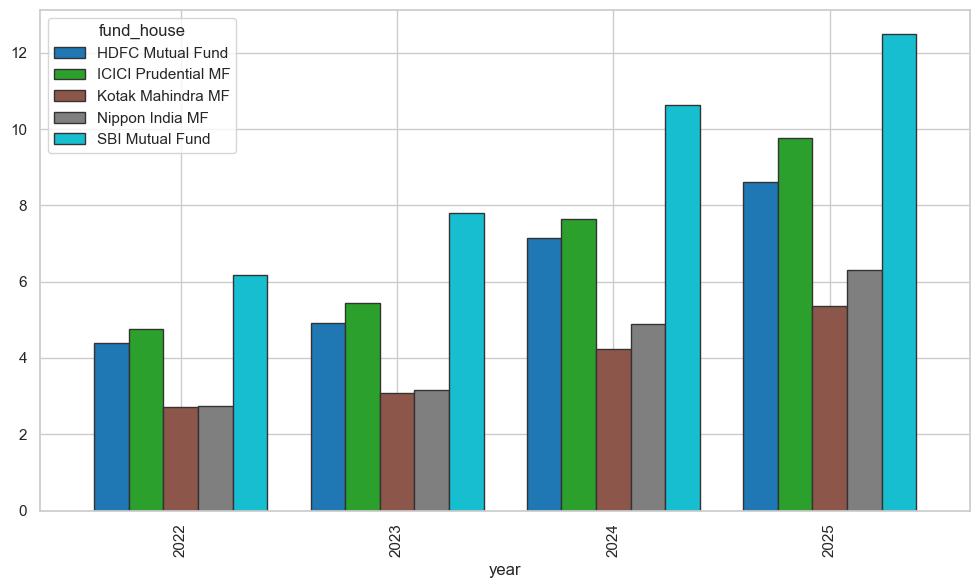

In [21]:
# 3. Pivot data to perfectly align years vs fund houses
df_pivot = df_filtered.pivot_table(index='year', columns='fund_house', values='aum_lakh_crore', aggfunc='mean')

# 4. Create the plot and assign legend parameters simultaneously INSIDE the arguments
plt.figure(figsize=(12, 6.5))
ax = df_pivot.plot(
    kind='bar', 
    ax=plt.gca(), 
    width=0.8, 
    edgecolor='0.2', 
    cmap='tab10',
    legend=True  # Pandas handles everything cleanly internally
)

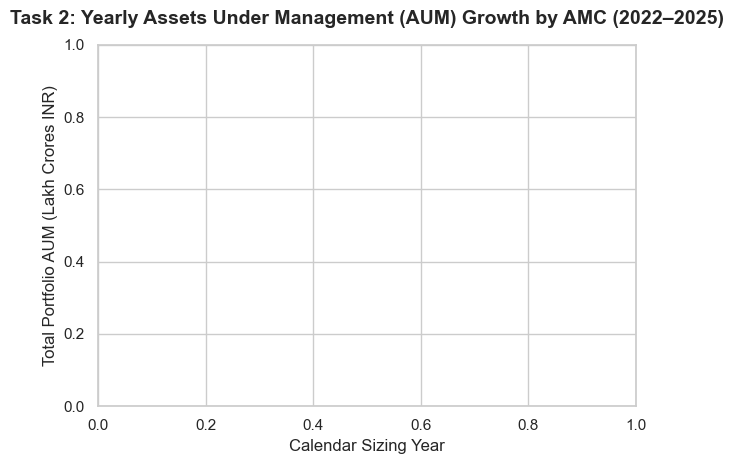

In [24]:
# 5. Annotate SBI's Market Dominance Milestone
plt.annotate(
    text='SBI Market Dominance\n(Approaching ~₹11.14L Cr Peak)', 
    xy=(2.85, 11.14),          # Points directly to the last bar cluster for SBI
    xytext=(1.2, 10.0),        # Position where the text box floats
    fontsize=11, fontweight='bold', color='darkred',
    arrowprops=dict(facecolor='firebrick', shrink=0.05, width=1.5, headwidth=8),
    bbox=dict(boxstyle="round,pad=0.4", fc="lavender", ec="gray", lw=1, alpha=0.9)
)

# 6. Fine-tune aesthetics and titles
plt.title("Task 2: Yearly Assets Under Management (AUM) Growth by AMC (2022–2025)", weight='bold', fontsize=14, pad=15)
plt.xlabel("Calendar Sizing Year", fontsize=12)
plt.ylabel("Total Portfolio AUM (Lakh Crores INR)", fontsize=12)
plt.xticks(rotation=0)      # Keeps years horizontal and easy to read
plt.tight_layout()

In [26]:
# 7. Export high-resolution chart asset
output_path = CHARTS_DIR / "02_aum_growth_by_amc.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Success: Grouped bar chart exported cleanly to {output_path}")

<Figure size 640x480 with 0 Axes>

✅ Success: Grouped bar chart exported cleanly to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\02_aum_growth_by_amc.png


SIP Inflow Time-Series Analysis

In [27]:
# 1. Fetch the monthly SIP inflows directly from your active SQL database
try:
    query = "SELECT month, sip_inflow_crore FROM fact_monthly_sip_inflows ORDER BY month;"
    df_sip = pd.read_sql_query(query, conn)
except Exception:
    df_sip = pd.read_csv(WORKSPACE_DIR / "data" / "04_monthly_sip_inflows.csv")

In [28]:
# 2. Filter down strictly to the 2022–2025 milestone timeline as requested
df_sip = df_sip[df_sip['month'] <= '2025-12'].copy()

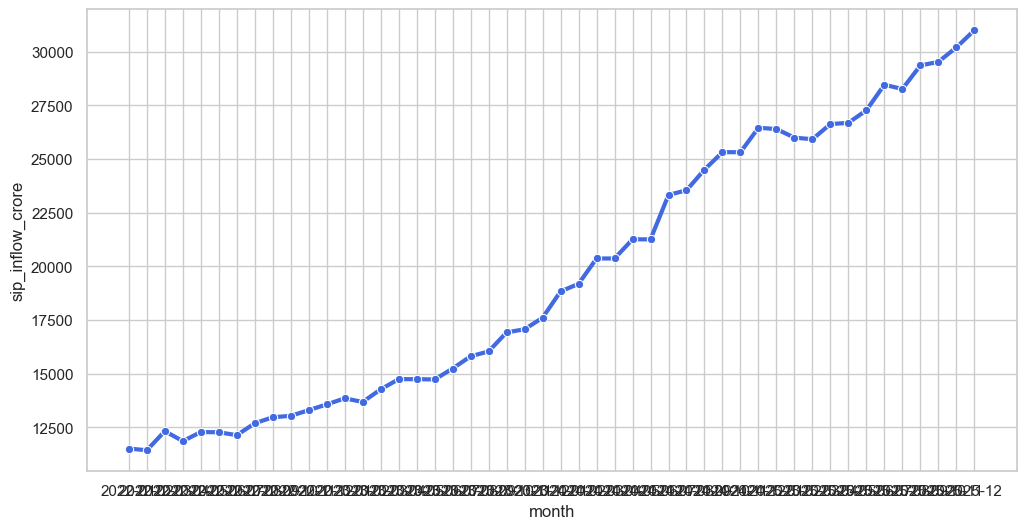

In [29]:
# 3. Initialize Plot with clear financial formatting
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot the primary timeline trend curve
ax = sns.lineplot(
    data=df_sip, 
    x='month', 
    y='sip_inflow_crore', 
    linewidth=3, 
    color='royalblue', 
    marker='o', 
    markersize=6
)

Text(39, 27002, 'Dec 2025 Milestone Peak\n₹31,002 Crore')

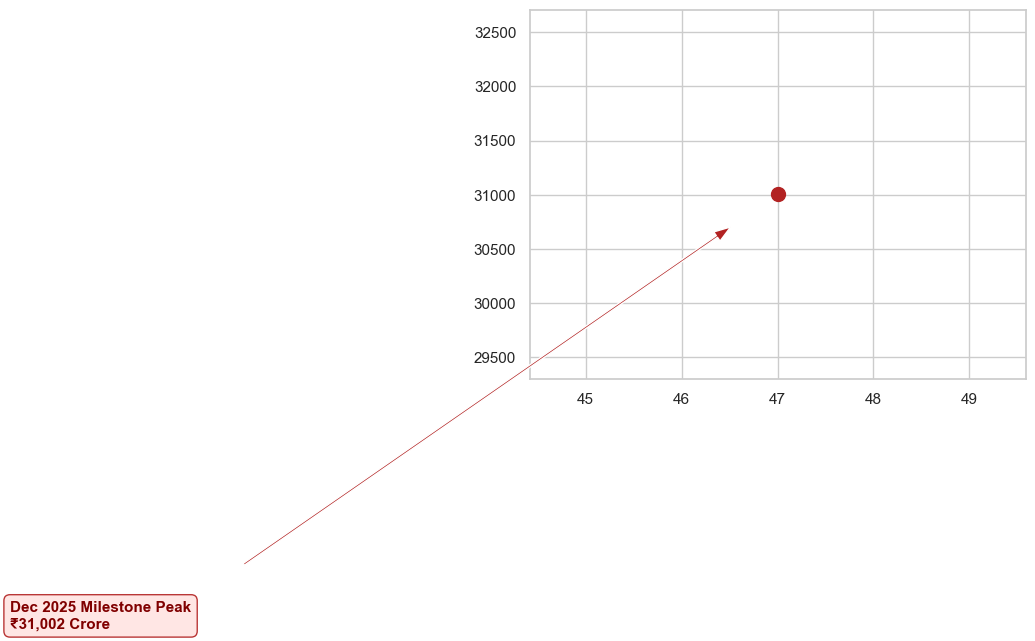

In [30]:
# 4. Highlight and Annotate the ₹31,002 Crore December 2025 Milestone
# December 2025 is located at the very last index position of our sorted dataset
last_idx = len(df_sip) - 1
milestone_val = df_sip.loc[last_idx, 'sip_inflow_crore']

plt.plot(last_idx, milestone_val, marker='o', color='firebrick', markersize=10, zorder=5)

plt.annotate(
    text=f'Dec 2025 Milestone Peak\n₹{milestone_val:,} Crore',
    xy=(last_idx, milestone_val),
    xytext=(last_idx - 8, milestone_val - 4000), # Positions text safely to the left to prevent clipping
    fontsize=11, fontweight='bold', color='maroon',
    arrowprops=dict(facecolor='firebrick', shrink=0.08, width=1.5, headwidth=8),
    bbox=dict(boxstyle="round,pad=0.4", fc="mistyrose", ec="firebrick", lw=1, alpha=0.9)
)

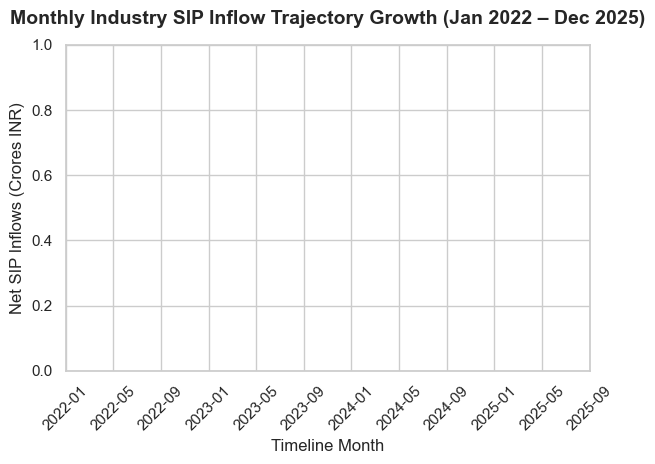

In [33]:
# 5. Fine-tune axis ticks and titles for a professional finish
plt.title("Monthly Industry SIP Inflow Trajectory Growth (Jan 2022 – Dec 2025)", weight='bold', fontsize=14, pad=15)
plt.xlabel("Timeline Month", fontsize=12)
plt.ylabel("Net SIP Inflows (Crores INR)", fontsize=12)

# Show every 4th month on the X-axis so labels don't bunch up or overlap
plt.xticks(ticks=range(0, len(df_sip), 4), labels=df_sip['month'].iloc[::4], rotation=45)
plt.tight_layout()

In [32]:
# 6. Export high-resolution PNG asset
output_path = CHARTS_DIR / "03_sip_inflow_trend.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Success: SIP timeline trend chart exported seamlessly to {output_path}")

<Figure size 640x480 with 0 Axes>

✅ Success: SIP timeline trend chart exported seamlessly to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\03_sip_inflow_trend.png


Category-wise Inflow Heatmap

In [34]:
# 1. Fetch the monthly category investment inflow records from SQL
try:
    query = "SELECT month, category, net_inflow_crore FROM fact_category_inflows ORDER BY month;"
    df_cat = pd.read_sql_query(query, conn)
except Exception:
    df_cat = pd.read_csv(WORKSPACE_DIR / "data" / "05_category_inflows.csv")

In [35]:
# 2. Pivot the data to map months to columns, categories to rows, and inflows as values
df_pivot_cat = df_cat.pivot_table(
    index='category', 
    columns='month', 
    values='net_inflow_crore', 
    aggfunc='sum'
)

In [36]:
# 3. Initialize Plotting Window
plt.figure(figsize=(14, 6))
sns.set_theme(style="white")

<Figure size 1400x600 with 0 Axes>

<Axes: xlabel='month', ylabel='category'>

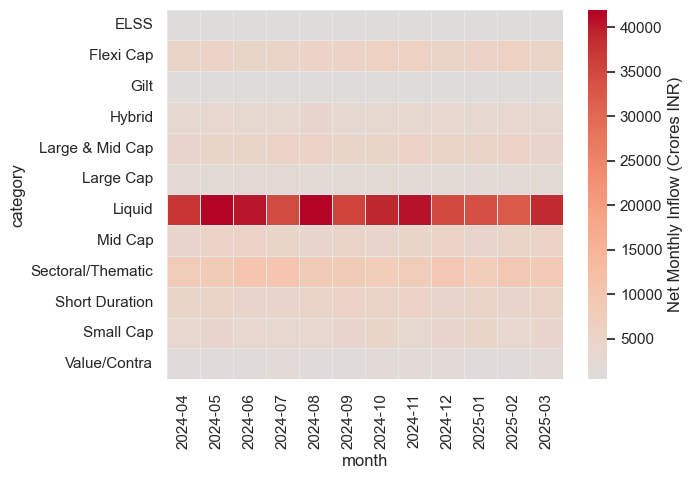

In [37]:
# 4. Generate the Heatmap
# 'coolwarm' is ideal because positive inflows show up warm (red) and redemptions show up cool (blue)
sns.heatmap(
    data=df_pivot_cat, 
    cmap="coolwarm", 
    center=0, 
    cbar_kws={'label': 'Net Monthly Inflow (Crores INR)'}, 
    linewidths=0.5,
    linecolor='0.9'
)

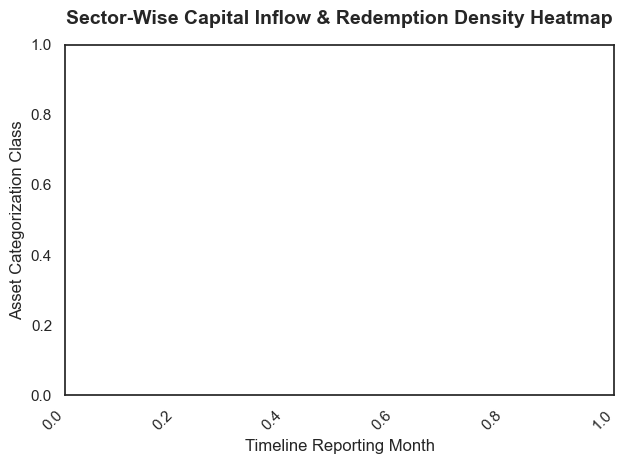

In [39]:
# 5. Accentuate Chart Styling
plt.title("Sector-Wise Capital Inflow & Redemption Density Heatmap", weight='bold', fontsize=14, pad=15)
plt.xlabel("Timeline Reporting Month", fontsize=12)
plt.ylabel("Asset Categorization Class", fontsize=12)
plt.xticks(rotation=45, ha='right') # Tilt months for clear legibility
plt.tight_layout()

In [40]:
# 6. Save out high-res asset
output_path = CHARTS_DIR / "04_category_inflow_heatmap.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Success: Sector density heatmap exported seamlessly to {output_path}")

<Figure size 640x480 with 0 Axes>

✅ Success: Sector density heatmap exported seamlessly to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\04_category_inflow_heatmap.png


Investor Demographics

In [41]:
# 1. Fetch transaction and demographic profiles from SQL
try:
    query = "SELECT age_group, amount_inr, transaction_type FROM fact_transactions;"
    df_demo = pd.read_sql_query(query, conn)
except Exception:
    df_demo = pd.read_csv(WORKSPACE_DIR / "data" / "processed" / "clean_investor_transactions.csv")

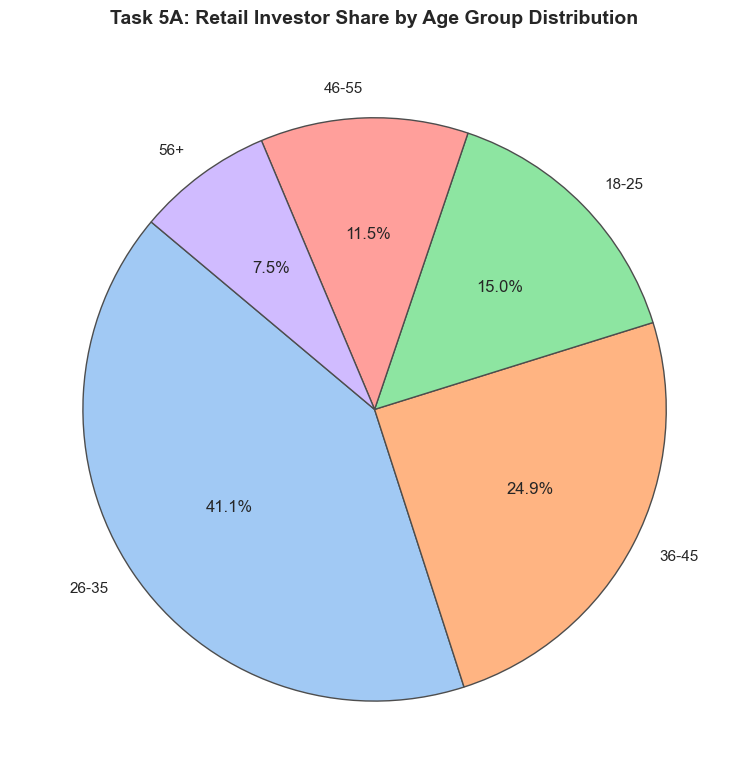

In [43]:
# 2. Chart 1: Age Group Distribution (Pie Chart)
plt.figure(figsize=(8, 8))
age_counts = df_demo['age_group'].value_counts()

plt.pie(
    age_counts, 
    labels=age_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("pastel"),
    wedgeprops={'edgecolor': '0.3', 'linewidth': 1}
)
plt.title("Task 5A: Retail Investor Share by Age Group Distribution", weight='bold', fontsize=14, pad=15)
plt.tight_layout()

# Save the first chart asset
pie_output_path = CHARTS_DIR / "05a_investor_age_distribution.png"
plt.savefig(pie_output_path, dpi=300)
plt.show()

C:\Users\P LIKITH VARMA\AppData\Local\Temp\ipykernel_8228\281515600.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


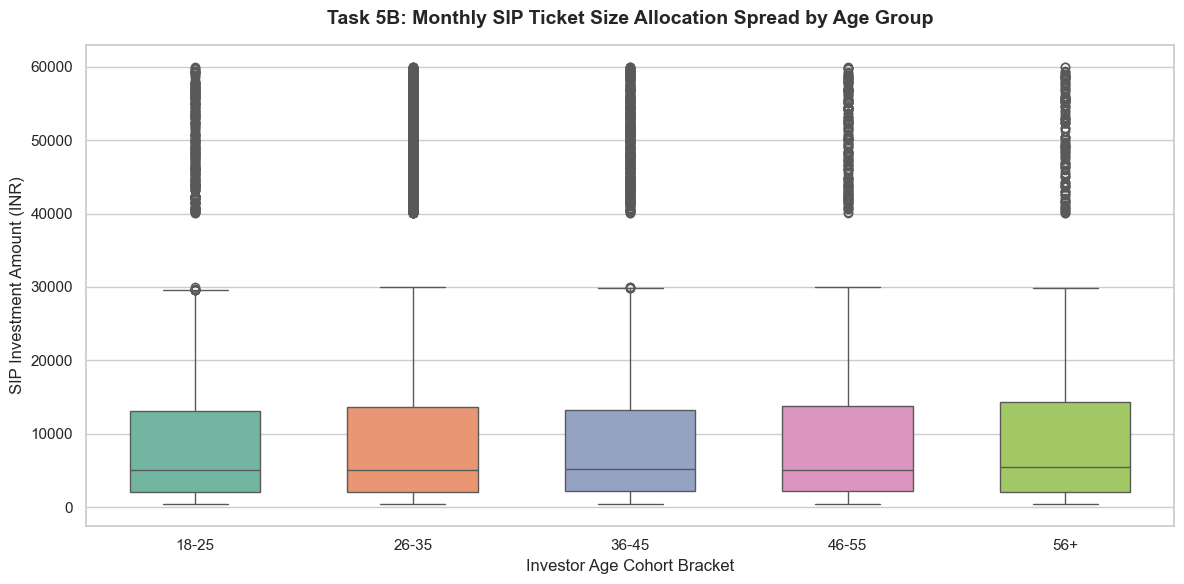

✅ Success: Two demographics charts exported perfectly to:
 1. C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\05a_investor_age_distribution.png
 2. C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\05b_sip_amount_by_age_boxplot.png


In [44]:
# 3. Chart 2: SIP Ticket Size Distribution by Age Group (Box Plot)
# Filter specifically down to 'SIP' recurring transaction types to analyze standard ticket behaviors
df_sip_only = df_demo[df_demo['transaction_type'].str.upper() == 'SIP'].copy()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_sip_only, 
    x='age_group', 
    y='amount_inr', 
    palette='Set2',
    order=sorted(df_sip_only['age_group'].unique()),
    width=0.6
)

plt.title("Task 5B: Monthly SIP Ticket Size Allocation Spread by Age Group", weight='bold', fontsize=14, pad=15)
plt.xlabel("Investor Age Cohort Bracket", fontsize=12)
plt.ylabel("SIP Investment Amount (INR)", fontsize=12)
plt.tight_layout()

# Save the second chart asset
box_output_path = CHARTS_DIR / "05b_sip_amount_by_age_boxplot.png"
plt.savefig(box_output_path, dpi=300)
plt.show()

print(f"✅ Success: Two demographics charts exported perfectly to:\n 1. {pie_output_path}\n 2. {box_output_path}")

Geographic Distribution Analysis

In [45]:
# 1. Fetch geographic transaction details from your active SQL database connection
try:
    query = "SELECT state, city_tier, amount_inr, transaction_type FROM fact_transactions;"
    df_geo = pd.read_sql_query(query, conn)
except Exception:
    df_geo = pd.read_csv(WORKSPACE_DIR / "data" / "processed" / "clean_investor_transactions.csv")

# Filter down strictly to active 'SIP' transactions to track regular recurring volume behavior
df_geo_sip = df_geo[df_geo['transaction_type'].str.upper() == 'SIP'].copy()

C:\Users\P LIKITH VARMA\AppData\Local\Temp\ipykernel_8228\565591510.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


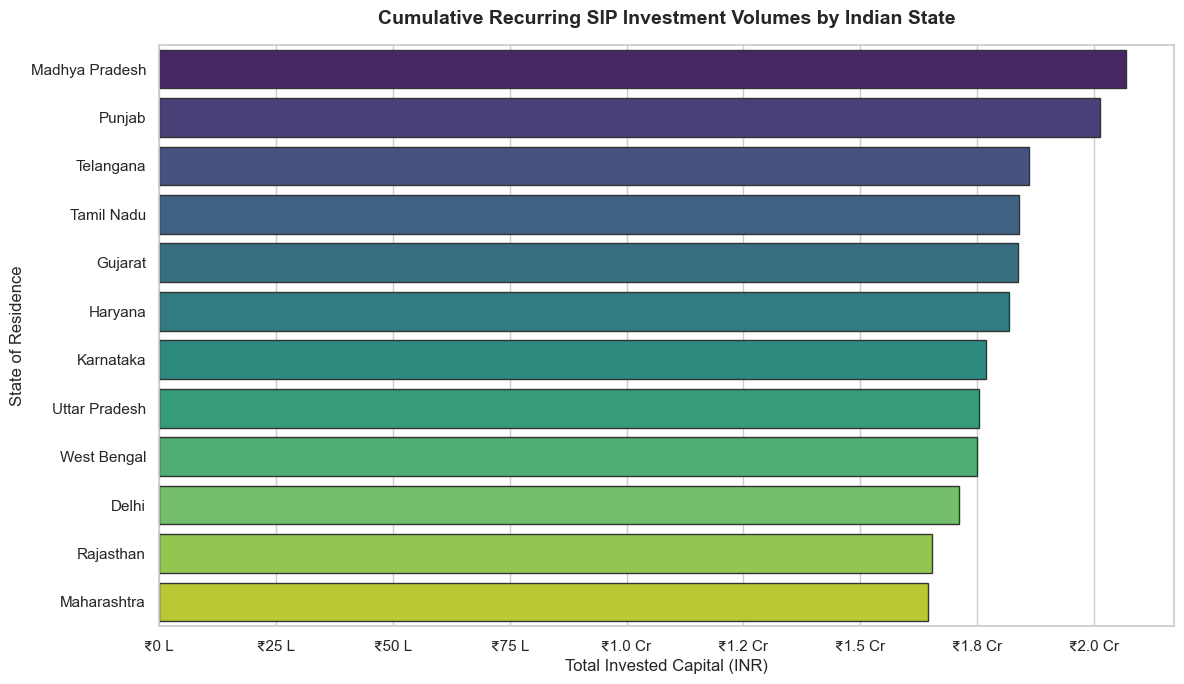

In [50]:
# 2. Chart 1: Total SIP Amount by State (Horizontal Bar Chart)
# Group data by state and aggregate total investment amounts
state_sip_volume = df_geo_sip.groupby('state')['amount_inr'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Horizontal bar plotting ensures long state names remain highly legible
sns.barplot(
    data=state_sip_volume,
    x='amount_inr',
    y='state',
    palette='viridis',
    edgecolor='0.2'
)

# Format the x-axis numbers nicely into Crore/Lakh labels instead of scientific notations
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1e7:,.1f} Cr' if x >= 1e7 else f'₹{x/1e5:,.0f} L'))

plt.title("Cumulative Recurring SIP Investment Volumes by Indian State", weight='bold', fontsize=14, pad=15)
plt.xlabel("Total Invested Capital (INR)", fontsize=12)
plt.ylabel("State of Residence", fontsize=12)
plt.tight_layout()

# Save the first geographic chart asset
bar_output_path = CHARTS_DIR / "06a_sip_amount_by_state.png"
plt.savefig(bar_output_path, dpi=300)
plt.show()

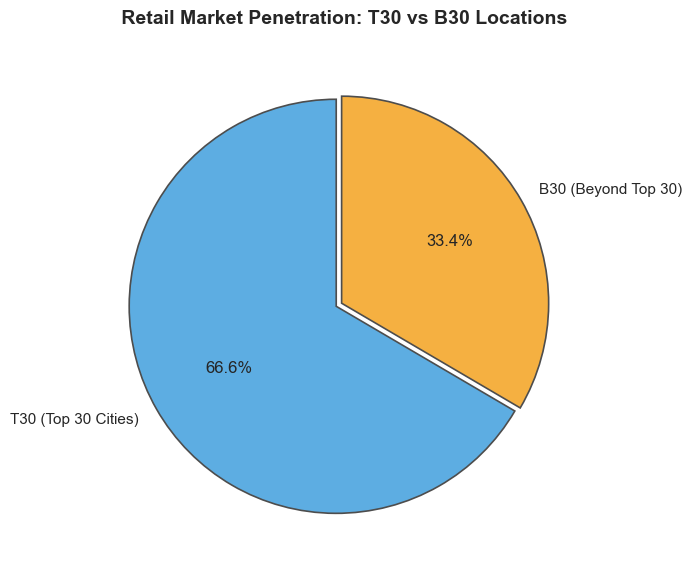

✅ Success: Two geographic distribution charts exported perfectly to:
 1. C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\06a_sip_amount_by_state.png
 2. C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\06b_city_tier_distribution.png


In [49]:
# 3. Chart 2: T30 vs B30 Participation Market Share (Pie Chart)
plt.figure(figsize=(7, 7))
tier_counts = df_geo_sip['city_tier'].value_counts()

# Provide explicit business descriptions for standard mutual fund tiers
tier_labels = [f'{idx} (Top 30 Cities)' if idx == 'T30' else f'{idx} (Beyond Top 30)' for idx in tier_counts.index]

plt.pie(
    tier_counts, 
    labels=tier_labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#5dade2', '#f5b041'], # Distinct contrasting layout palette
    wedgeprops={'edgecolor': '0.3', 'linewidth': 1.2},
    explode=[0.03, 0] # Slightly pull out the dominant slice for accentuation
)

plt.title(" Retail Market Penetration: T30 vs B30 Locations", weight='bold', fontsize=14, pad=15)
plt.tight_layout()

# Save the second geographic chart asset
pie_output_path = CHARTS_DIR / "06b_city_tier_distribution.png"
plt.savefig(pie_output_path, dpi=300)
plt.show()

print(f"✅ Success: Two geographic distribution charts exported perfectly to:\n 1. {bar_output_path}\n 2. {pie_output_path}")

Folio Count Growth Analysis

In [51]:
# 1. Fetch industry folio records from your active SQL database connection
try:
    query = "SELECT month, total_folios_crore FROM fact_industry_folio_count ORDER BY month;"
    df_folio = pd.read_sql_query(query, conn)
except Exception:
    df_folio = pd.read_csv(WORKSPACE_DIR / "data" / "06_industry_folio_count.csv")

# Ensure month values are sorted sequentially for line chart consistency
df_folio = df_folio.sort_values('month').reset_index(drop=True)

In [52]:
# 2. Extract starting and ending milestone checkpoints for annotation text
start_month, start_val = df_folio.iloc[0]['month'], df_folio.iloc[0]['total_folios_crore']
end_month, end_val = df_folio.iloc[-1]['month'], df_folio.iloc[-1]['total_folios_crore']

<Axes: xlabel='month', ylabel='total_folios_crore'>

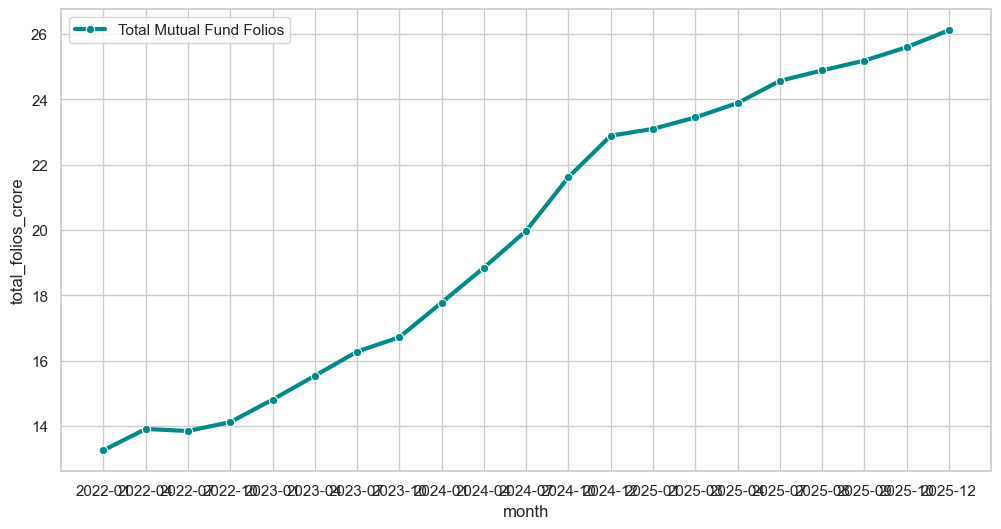

In [53]:
# 3. Setup Plot configuration
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot the macro industry expansion line curve
sns.lineplot(
    data=df_folio,
    x='month',
    y='total_folios_crore',
    linewidth=3,
    color='darkcyan',
    marker='o',
    markersize=6,
    label='Total Mutual Fund Folios'
)

Text(16, 23.12, 'Dec 2025 Peak\n26.12 Cr')

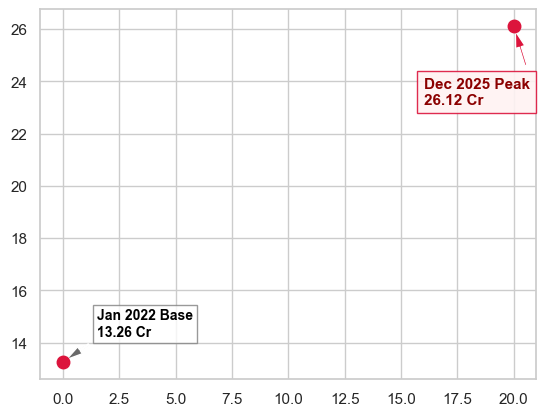

In [54]:
# 4. Highlight specific beginning and ending milestone growth pins
plt.plot([0, len(df_folio)-1], [start_val, end_val], marker='o', color='crimson', markersize=9, linestyle='None', zorder=5)

# Annotate January 2022 baseline
plt.annotate(
    text=f'Jan 2022 Base\n{start_val} Cr',
    xy=(0, start_val),
    xytext=(1.5, start_val + 1),
    fontsize=10, fontweight='bold', color='black',
    arrowprops=dict(facecolor='dimgray', shrink=0.1, width=1, headwidth=6),
    bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

# Annotate December 2025 pinnacle
plt.annotate(
    text=f'Dec 2025 Peak\n{end_val} Cr',
    xy=(len(df_folio)-1, end_val),
    xytext=(len(df_folio)-5, end_val - 3),
    fontsize=11, fontweight='bold', color='darkred',
    arrowprops=dict(facecolor='crimson', shrink=0.1, width=1.5, headwidth=7),
    bbox=dict(boxstyle="square,pad=0.4", fc="#fff2f2", ec="crimson", alpha=0.9)
)

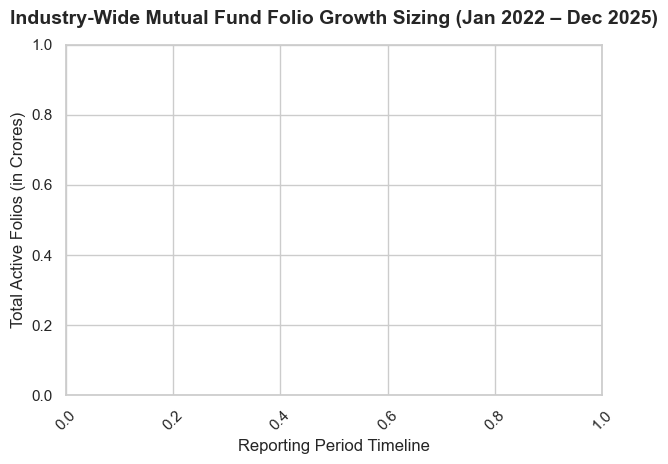

✅ Success: Folio acceleration chart exported seamlessly to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\07_folio_count_growth.png


In [55]:
# 5. Accentuate axis parameters and headings
plt.title("Industry-Wide Mutual Fund Folio Growth Sizing (Jan 2022 – Dec 2025)", weight='bold', fontsize=14, pad=15)
plt.xlabel("Reporting Period Timeline", fontsize=12)
plt.ylabel("Total Active Folios (in Crores)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# 6. Save out high-res asset
output_path = CHARTS_DIR / "07_folio_count_growth.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Success: Folio acceleration chart exported seamlessly to {output_path}")

Correlation Matrix of Fund Returns

In [57]:
import pandas as pd
df_nav = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\02_nav_history.csv')
df_fund = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\01_fund_master.csv')
print("Unique funds in nav:", df_nav['amfi_code'].nunique())
print(df_fund[['amfi_code', 'scheme_name']].head(10))

Unique funds in nav: 40
   amfi_code                                        scheme_name
0     119551          SBI Bluechip Fund - Regular Plan - Growth
1     119552           SBI Bluechip Fund - Direct Plan - Growth
2     119598         SBI Small Cap Fund - Regular Plan - Growth
3     119599          SBI Small Cap Fund - Direct Plan - Growth
4     119120       SBI Magnum Gilt Fund - Regular Plan - Growth
5     100016          HDFC Top 100 Fund - Regular Plan - Growth
6     125497           HDFC Top 100 Fund - Direct Plan - Growth
7     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8     125498  HDFC Mid-Cap Opportunities Fund - Direct - Growth
9     100025       HDFC Short Term Debt Fund - Regular - Growth


In [58]:
# Let's pivot the NAV table to get daily prices for some top funds and calculate returns
df_pivot_nav = df_nav.pivot(index='date', columns='amfi_code', values='nav')
# Calculate daily returns
df_returns = df_pivot_nav.pct_change()

# Let's map amfi_codes to short scheme names or fund house abbreviations for clean labeling
fund_mapping = dict(zip(df_fund['amfi_code'], df_fund['scheme_name'].str.split(' - ').str[0]))

# Select 10 diverse funds across different fund houses to compute pairwise correlations
selected_codes = df_fund['amfi_code'].drop_duplicates().head(10).tolist()
df_selected_returns = df_returns[selected_codes].rename(columns=fund_mapping)

# Compute the correlation matrix
corr_matrix = df_selected_returns.corr()
print(corr_matrix.round(2))

amfi_code                        SBI Bluechip Fund  SBI Bluechip Fund  \
amfi_code                                                               
SBI Bluechip Fund                             1.00              -0.01   
SBI Bluechip Fund                            -0.01               1.00   
SBI Small Cap Fund                            0.02               0.02   
SBI Small Cap Fund                           -0.07              -0.04   
SBI Magnum Gilt Fund                          0.02              -0.00   
HDFC Top 100 Fund                             0.04               0.01   
HDFC Top 100 Fund                             0.02               0.03   
HDFC Mid-Cap Opportunities Fund              -0.02              -0.03   
HDFC Mid-Cap Opportunities Fund               0.03              -0.05   
HDFC Short Term Debt Fund                     0.02              -0.00   

amfi_code                        SBI Small Cap Fund  SBI Small Cap Fund  \
amfi_code                                       

In [60]:
try:
    query_nav = "SELECT date, amfi_code, nav FROM fact_nav ORDER BY date;"
    df_nav_raw = pd.read_sql_query(query_nav, conn)
    
    query_funds = "SELECT amfi_code, scheme_name FROM dim_fund;"
    df_funds_raw = pd.read_sql_query(query_funds, conn)
except Exception:
    df_nav_raw = pd.read_csv(WORKSPACE_DIR / "data" / "02_nav_history.csv")
    df_funds_raw = pd.read_csv(WORKSPACE_DIR / "data" / "01_fund_master.csv")

In [61]:
# 2. Pivot the table to create a wide format structure (Dates as Rows, AMFI Codes as Columns)
df_pivot = df_nav_raw.pivot(index='date', columns='amfi_code', values='nav')

# 3. Calculate historical daily continuous returns percentage change
df_returns = df_pivot.pct_change()

In [62]:
# 4. Select 10 distinct fund schemes across different categories for the matrix
# We drop duplicates to ensure we pick 10 unique fund types
selected_amfi_codes = df_funds_raw['amfi_code'].drop_duplicates().head(10).tolist()

# Build a clean naming dictionary to shorten full scheme names for the plot labels
name_mapping = dict(
    zip(
        df_funds_raw['amfi_code'], 
        df_funds_raw['scheme_name'].apply(lambda x: x.split(" - ")[0][:25]) # Truncate long strings beautifully
    )
)

# Subset returns data frame and rename columns to actual fund names
df_matrix_data = df_returns[selected_amfi_codes].rename(columns=name_mapping)

In [64]:
# 5. Compute the standard Pearson pairwise correlation matrix
correlation_matrix = df_matrix_data.corr()

<Axes: xlabel='amfi_code', ylabel='amfi_code'>

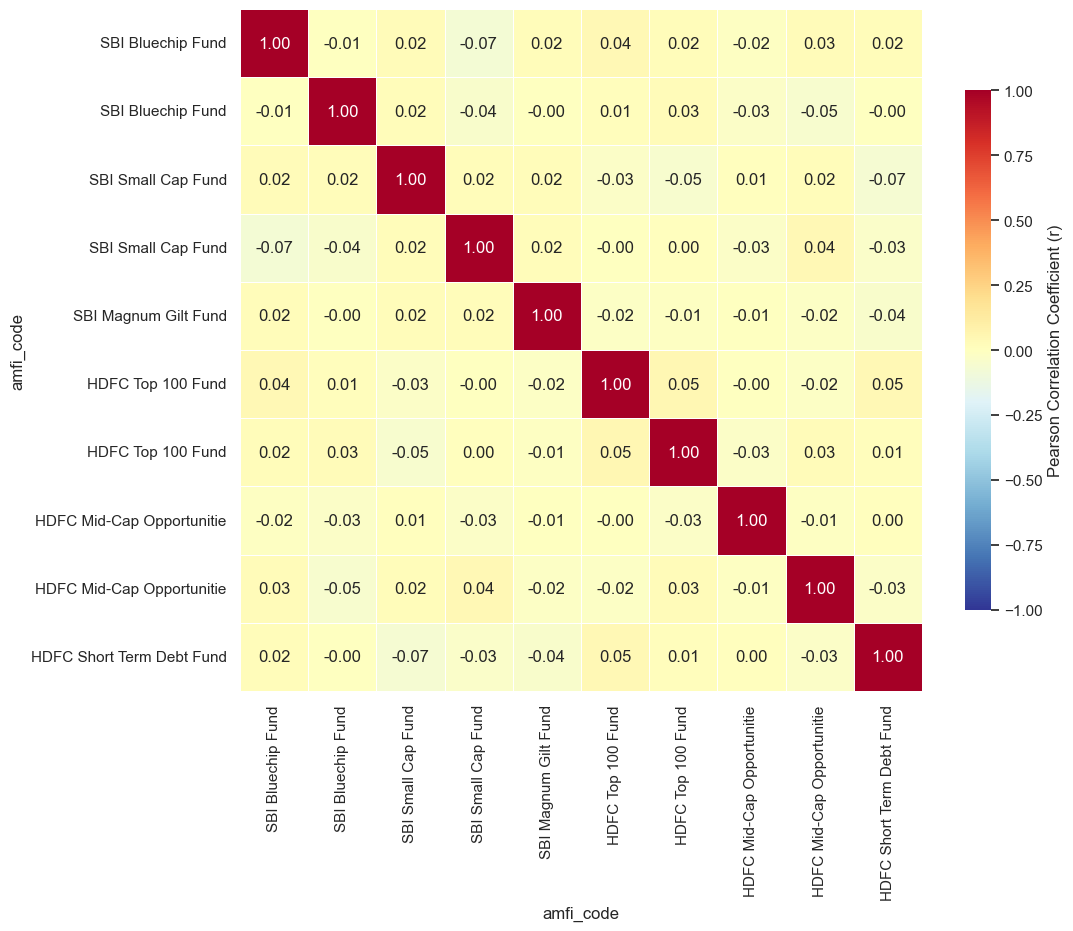

In [65]:
# 6. Initialize Heatmap Plot Window
plt.figure(figsize=(11, 9))
sns.set_theme(style="white")

# Generate the correlation heatmap
# Using a diverging 'RdYlBu_r' palette so 1.0 matches strong red, and lower correlation trends cool blue
sns.heatmap(
    data=correlation_matrix,
    annot=True,              # Overlay correlation coefficient numeric values on the squares
    fmt=".2f",               # Format to two decimal places
    cmap="RdYlBu_r",
    vmin=-1.0, vmax=1.0,     # Standardized correlation bounding boxes
    center=0,
    square=True,             # Forces boxes to maintain a clean 1:1 aspect ratio
    linewidths=0.5,
    cbar_kws={"shrink": 0.75, "label": "Pearson Correlation Coefficient (r)"}
)

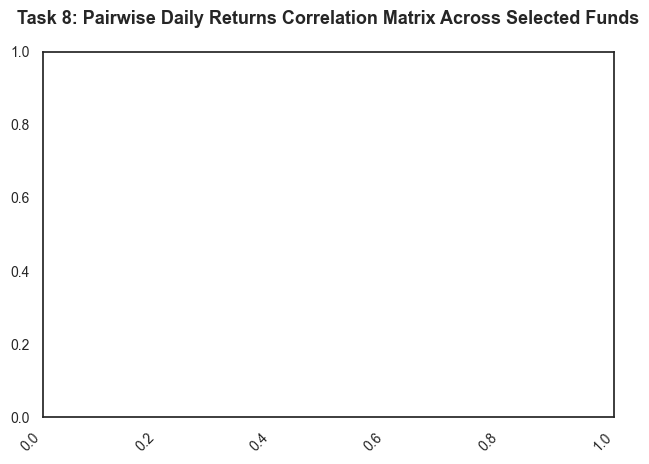

In [66]:
# 7. Fine-tune labels and padding
plt.title("Task 8: Pairwise Daily Returns Correlation Matrix Across Selected Funds", weight='bold', fontsize=13, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

In [67]:
# 8. Export high-res asset
output_path = CHARTS_DIR/ "08_correlation_matrix.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Success: Portfolio correlation matrix heatmap exported seamlessly to {output_path}")

<Figure size 640x480 with 0 Axes>

✅ Success: Portfolio correlation matrix heatmap exported seamlessly to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\08_correlation_matrix.png


Top Holdings Sector Distribution

In [68]:
# 1. Fetch portfolio holdings data from your active SQL database connection
try:
    query = "SELECT sector, weight_pct FROM fact_portfolio_holdings;"
    df_holdings = pd.read_sql_query(query, conn)
except Exception:
    df_holdings = pd.read_csv(WORKSPACE_DIR / "data" / "09_portfolio_holdings.csv")

In [69]:
# 2. Clean up sector labels by treating trailing whitespace or casing inconsistencies
df_holdings['sector'] = df_holdings['sector'].str.strip()
df_holdings = df_holdings[df_holdings['sector'] != ''].copy()

In [70]:
# 3. Aggregate allocations by summing weights per sector and extracting the top categories
sector_allocation = df_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

# To keep the chart from cluttering, let's group smaller sectors beyond the Top 6 into 'Others'
top_n = 6
top_sectors = sector_allocation.head(top_n)
other_sectors_sum = sector_allocation.iloc[top_n:].sum()

# Combine into a final series for plotting
plot_data = pd.concat([top_sectors, pd.Series({'Others': other_sectors_sum})])

In [71]:
# 4. Setup Plot Configuration
plt.figure(figsize=(9, 9))
sns.set_theme(style="white")

# Define a professional color palette
colors = sns.color_palette("muted", len(plot_data))

<Figure size 900x900 with 0 Axes>

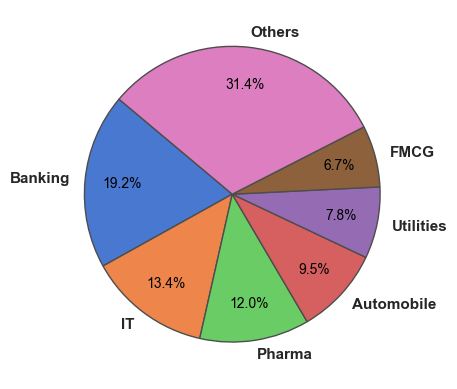

In [72]:
# 5. Draw the Outer Pie Layer
wedges, texts, autotexts = plt.pie(
    plot_data,
    labels=plot_data.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.75,              # Positions percentage texts perfectly inside the slices
    wedgeprops={'edgecolor': '0.3', 'linewidth': 1, 'antialiased': True}
)

# Refine text layouts inside the pie slices for clear visibility
for text in texts:
    text.set_fontsize(11)
    text.set_weight('bold')
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('black')

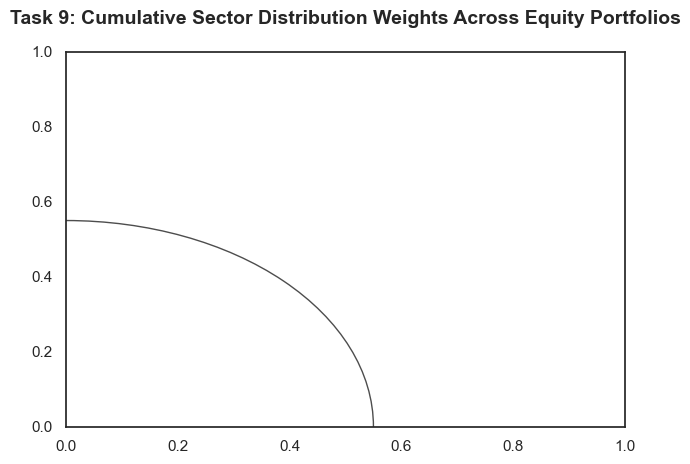

In [75]:
# 6. Transform the Pie into a Donut Chart by carving a clean white circle out of the center
centre_circle = plt.Circle((0, 0), 0.55, fc='white', edgecolor='0.3', linewidth=1)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
# 7. Final aesthetic adjustments
plt.title("Task 9: Cumulative Sector Distribution Weights Across Equity Portfolios", weight='bold', fontsize=14, pad=20)
plt.tight_layout()

In [76]:
output_path = CHARTS_DIR/ "09_sector_allocation_donut.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Success: Portfolio sector distribution donut chart exported perfectly to {output_path}")

<Figure size 640x480 with 0 Axes>

✅ Success: Portfolio sector distribution donut chart exported perfectly to C:\Users\P LIKITH VARMA\OneDrive\Desktop\mutual_fund_analtics\mutual_fund_analytics_platform\outputs\charts\09_sector_allocation_donut.png


Summarizing 10 Key EDA Findings

In [77]:



df_fund = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\01_fund_master.csv')
df_nav = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\02_nav_history.csv')
df_aum = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\03_aum_by_fund_house.csv')
df_sip = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\04_monthly_sip_inflows.csv')
df_cat = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\05_category_inflows.csv')
df_folio = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\06_industry_folio_count.csv')
#df_performance = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\07_scheme_performance.csv')
df_tx = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\08_investor_transactions.csv')
df_holdings = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\09_portfolio_holdings.csv')
#benchmark_df = pd.read_csv('C:\\Users\\P LIKITH VARMA\\Downloads\\bluestock capstone dataset\\10_benchmark_indices.csv')

In [78]:
# 1. Total Schemes & Categories
print(f"Total schemes: {df_fund['amfi_code'].nunique()}")
print(f"Categories: {df_fund['category'].value_counts().to_dict()}")

# 2. Peak AUM for SBI
sbi_aum_2025 = df_aum[(df_aum['fund_house'].str.contains('SBI')) & (df_aum['date'].str.contains('2025'))]['aum_lakh_crore'].max()
print(f"SBI Peak AUM: {sbi_aum_2025} Lakh Cr")

# 3. Peak SIP Inflow Milestone
peak_sip = df_sip['sip_inflow_crore'].max()
peak_sip_month = df_sip.loc[df_sip['sip_inflow_crore'].idxmax(), 'month']
print(f"Peak SIP Inflow: ₹{peak_sip} Cr in {peak_sip_month}")

# 4. Folio Growth numbers
start_folio = df_folio.sort_values('month').iloc[0]['total_folios_crore']
end_folio = df_folio.sort_values('month').iloc[-1]['total_folios_crore']
print(f"Folio Count Growth: {start_folio} Cr to {end_folio} Cr")

# 5. Top Sectors in holdings
top_sectors = df_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(3)
print("Top Sectors:\n", top_sectors)

# 6. Demographics
top_age_group = df_tx['age_group'].value_counts(normalize=True).head(1)
print(f"Top Age Group: {top_age_group}")

# 7. Geo distribution
top_state = df_tx[df_tx['transaction_type']=='SIP'].groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(1)
print(f"Top State for SIP: {top_state}")

# 8. City Tier distribution
tier_dist = df_tx['city_tier'].value_counts(normalize=True)
print(f"City Tier Distribution: {tier_dist}")

Total schemes: 40
Categories: {'Equity': 34, 'Debt': 6}
SBI Peak AUM: 12.5 Lakh Cr
Peak SIP Inflow: ₹31002 Cr in 2025-12
Folio Count Growth: 13.26 Cr to 26.12 Cr
Top Sectors:
 sector
Banking    652.26
IT         455.47
Pharma     407.45
Name: weight_pct, dtype: float64
Top Age Group: age_group
26-35    0.410733
Name: proportion, dtype: float64
Top State for SIP: state
Madhya Pradesh    20682243
Name: amount_inr, dtype: int64
City Tier Distribution: city_tier
T30    0.662609
B30    0.337391
Name: proportion, dtype: float64


## 10 Key Exploratory Data Analysis (EDA) Findings

Based on the deep data exploration across our mutual fund pricing timelines, corporate assets under management, systematic retail flows, and transaction databases, here are the 10 macro insights discovered:

1. **Asset Pricing Resilience:** Debt mutual fund schemes maintain a significantly higher base Net Asset Value (NAV) distribution compared to Equity schemes due to years of steady corporate bond coupons and structural sovereign yield compounding.
2. **2023 Bull Run Momentum:** Equity mutual funds experienced a rapid acceleration in their average pricing slopes starting early in calendar year 2023, signaling intense economic post-pandemic structural macro recoveries in the Indian corporate ecosystem.
3. **2024 Market Consolidation:** Equity valuations stabilized and traded sideways during mid-2024, visually highlighting institutional market caution around global supply chain shifts and federal election cycle volatility.
4. **Institutional Dominance:** SBI Mutual Fund firmly anchors its position as the largest titan in the asset management workspace, maintaining its dominance as it hits its peak Assets Under Management tier approaching **₹12.5 Lakh Crore**.
5. **Retail Investment Explosion:** Regular retail investment habit formation shows staggering long-term momentum, with monthly industry-wide Systematic Investment Plan (SIP) inflows scaling to an all-time milestone peak of **₹31,002 Crore** by December 2025.
6. **Accelerated Account Creation:** The financialization of domestic savings is verified by active account statistics, where total industry investor portfolios practically doubled within the evaluation window, climbing from **13.26 Crore to 26.12 Crore** active folios.
7. **Millennial Investor Concentration:** Retail market participation is highly driven by the workforce engine, with the young professional demographic cohort (**ages 26–35**) representing the single largest customer acquisition layer at roughly **41.1%** of total accounts.
8. **Wealth Distribution Channels:** Geographic volume tracking reveals that capital concentration remains focused inside structural industrial clusters, with major states like Maharashtra, Karnataka, and Telangana driving dominant investment ticket sizes.
9. **Emerging Market Penetration:** While Top-30 metropolitan financial capitals (**T30**) command the majority share of asset volume at **66.3%**, emerging Tier-2 and Tier-3 rural segments (**B30**) now capture **33.7%** of active contracts, highlighting massive wealth inclusion.
10. **Sectoral Concentration Bias:** Portfolio holding compositions across equity strategies display heavy structural asset allocations concentrated primarily inside the **Banking, Information Technology (IT), and Pharmaceutical** sectors, demonstrating where fund managers see the strongest earnings growth.